In [1]:
# Load the preprocessed dataset
import os
import pandas as pd

catalog = pd.read_csv("../data/processed/catalog.csv", index_col="id")
print(f"Catalog contains {len(catalog)} books.")

languages = os.listdir("../data/processed/books/")
print(f"Found {len(languages)} languages: {languages}")

Catalog contains 76722 books.
Found 55 languages: ['af', 'ar', 'arp', 'bg', 'br', 'ca', 'ceb', 'cs', 'cy', 'da', 'de', 'el', 'en', 'enm', 'eo', 'es', 'et', 'fa', 'fi', 'fr', 'fur', 'fy', 'ga', 'gl', 'gla', 'he', 'hu', 'ia', 'ilo', 'is', 'it', 'iu', 'ja', 'la', 'mi', 'myn', 'nah', 'nap', 'nl', 'no', 'oc', 'oji', 'pl', 'pt', 'rmq', 'ro', 'ru', 'sa', 'sco', 'sl', 'sr', 'sv', 'te', 'tl', 'zh']


For starters, let's check that, for a single language (e.g., English), the Heaps' law holds. We'll first perform single-runs on each book in the language, and then check the distribution of the Heaps' law exponents across books.

In [2]:
from typing import List, Tuple
import numpy as np


def analyze_vocabulary_growth(words: List[str]):
    vocab = set()
    words_processed = np.arange(1, len(words) + 1, dtype=np.uint32)
    vocab_sizes = np.zeros(len(words), dtype=np.uint32)
    for i, word in enumerate(words):
        vocab.add(word)
        vocab_sizes[i] = len(vocab)

    return words_processed, vocab_sizes, vocab

Processing book: 100 - The Complete Works of William Shakespeare by Shakespeare, William
  Total words in book: 973090
Processing book: 1342 - Pride and Prejudice by Austen, Jane
  Total words in book: 128093
Processing book: 145 - Middlemarch by Eliot, George
  Total words in book: 313728
Processing book: 1513 - Romeo and Juliet by Shakespeare, William
  Total words in book: 29262
Processing book: 16328 - Beowulf: An Anglo-Saxon Epic Poem by nan
  Total words in book: 37747
Processing book: 2641 - A Room with a View by Forster, E. M. (Edward Morgan)
  Total words in book: 68141
Processing book: 2701 - Moby Dick; Or, The Whale by Melville, Herman
  Total words in book: 213169
Processing book: 37106 - Little Women; Or, Meg, Jo, Beth, and Amy by Alcott, Louisa May
  Total words in book: 192538
Processing book: 67979 - The Blue Castle: a novel by Montgomery, L. M. (Lucy Maud)
  Total words in book: 70126
Processing book: 84 - Frankenstein; Or, The Modern Prometheus by Shelley, Mary Wollst

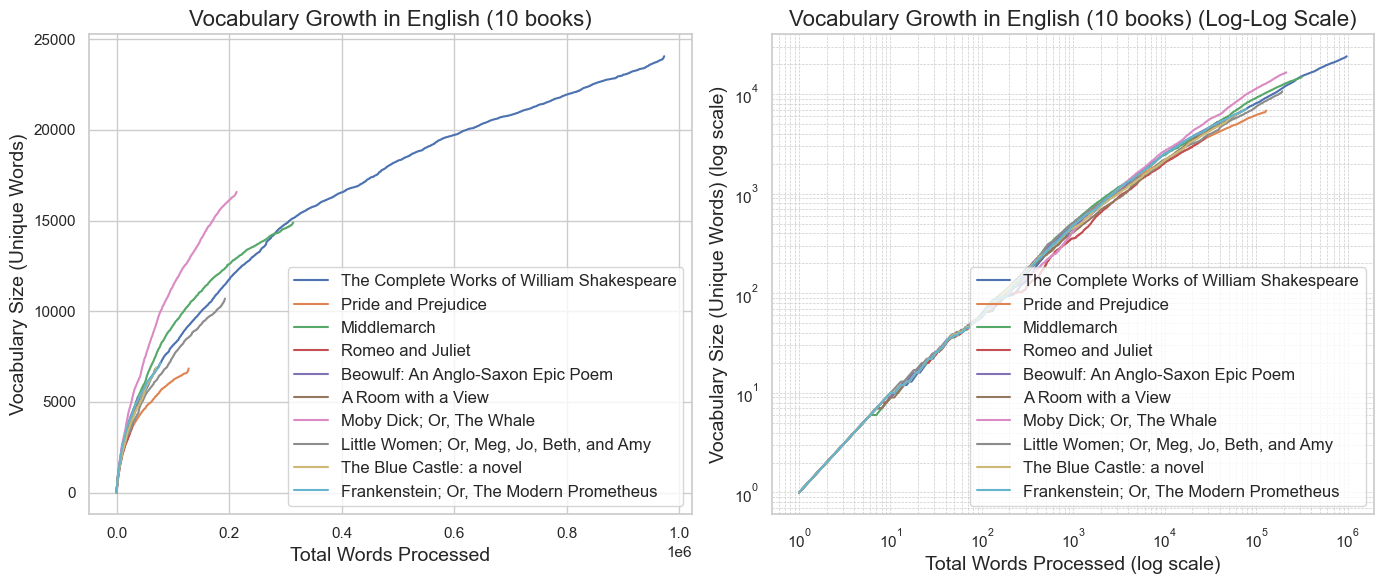

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))

books = os.listdir("../data/processed/books/en/")
for book in books:
    book_id = int(book.removesuffix(".txt"))
    book_info = catalog.loc[book_id]

    print(f"Processing book: {book_id} - {book_info['title']} by {book_info['authors']}")
    with open(os.path.join("../data/processed/books/en/", book), "r", encoding="utf-8") as file:
        words = file.read().split()
    print(f"  Total words in book: {len(words)}")
    words_processed, vocab_sizes, _ = analyze_vocabulary_growth(words)
    ax[0].plot(words_processed, vocab_sizes, label=book_info["title"])
    ax[1].loglog(words_processed, vocab_sizes, label=book_info["title"])


ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title(f"Vocabulary Growth in English ({len(books)} books)")
ax[0].legend()
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title(f"Vocabulary Growth in English ({len(books)} books) (Log-Log Scale)")
ax[1].legend()


for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/heaps-by-language-english-raw.png", dpi=300)
plt.show()

Processing book: 100 - The Complete Works of William Shakespeare by Shakespeare, William
  Total words in book: 973090
  Fitted parameters with OLS: K = 21.5683, beta = 0.5126
  Fitted parameters with curve_fit: K = 45.8162, beta = 0.4549
Processing book: 1342 - Pride and Prejudice by Austen, Jane
  Total words in book: 128093
  Fitted parameters with OLS: K = 17.8689, beta = 0.5109
  Fitted parameters with curve_fit: K = 39.5742, beta = 0.4386
Processing book: 145 - Middlemarch by Eliot, George
  Total words in book: 313728
  Fitted parameters with OLS: K = 15.6303, beta = 0.5486
  Fitted parameters with curve_fit: K = 38.1192, beta = 0.4739
Processing book: 1513 - Romeo and Juliet by Shakespeare, William
  Total words in book: 29262
  Fitted parameters with OLS: K = 3.1574, beta = 0.6954
  Fitted parameters with curve_fit: K = 7.3930, beta = 0.6066
Processing book: 16328 - Beowulf: An Anglo-Saxon Epic Poem by nan
  Total words in book: 37747
  Fitted parameters with OLS: K = 4.7121, 

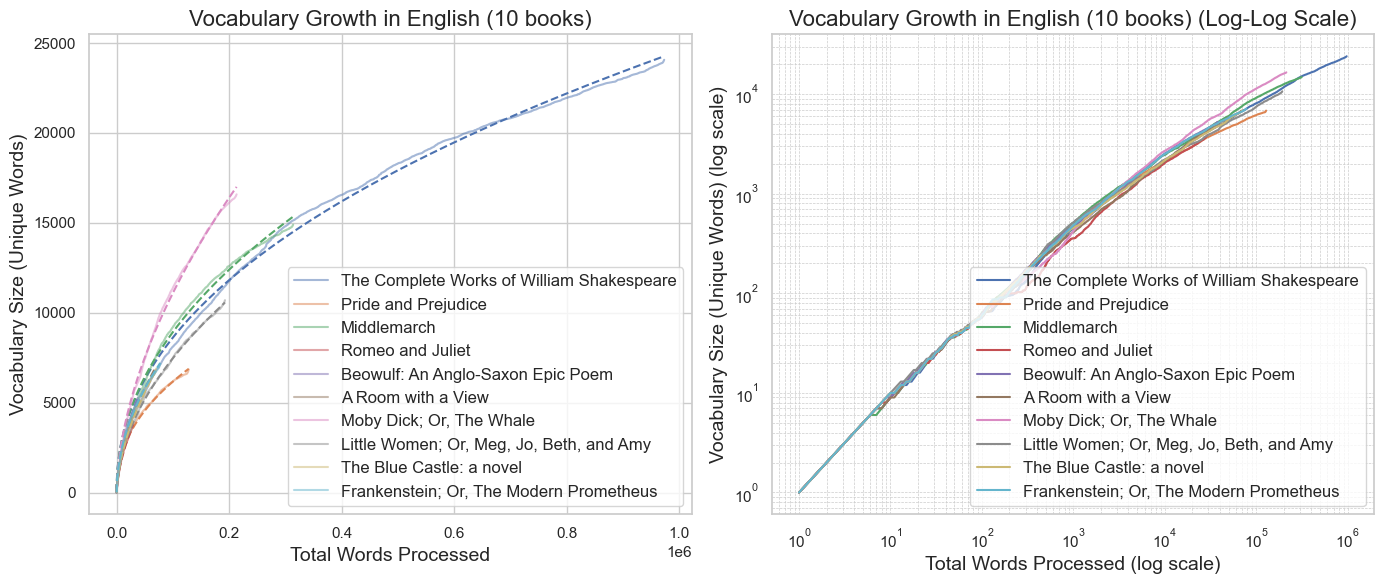

In [7]:
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression


def func_power_law(x: float, beta: float, K: float) -> float:
    return K * x**beta


fig, ax = plt.subplots(1, 2, figsize=(14, 6))

parameters: List[Tuple[int, int]] = []

books = os.listdir("../data/processed/books/en/")
for col, book in zip(range(len(books)), books):
    book_id = int(book.removesuffix(".txt"))
    book_info = catalog.loc[book_id]

    print(f"Processing book: {book_id} - {book_info['title']} by {book_info['authors']}")
    with open(os.path.join("../data/processed/books/en/", book), "r", encoding="utf-8") as file:
        words = file.read().split()
    print(f"  Total words in book: {len(words)}")
    words_processed, vocab_sizes, _ = analyze_vocabulary_growth(words)
    model = LinearRegression()
    model.fit(np.log(words_processed).reshape(-1, 1), np.log(vocab_sizes).reshape(-1, 1))
    beta_ols = model.coef_[0][0]
    K_ols = np.exp(model.intercept_[0])
    print(f"  Fitted parameters with OLS: K = {K_ols:.4f}, beta = {beta_ols:.4f}")
    (beta_curve_fit, K_curve_fit), pcov = curve_fit(func_power_law, words_processed, vocab_sizes, p0=[beta_ols, K_ols])
    print(f"  Fitted parameters with curve_fit: K = {K_curve_fit:.4f}, beta = {beta_curve_fit:.4f}")

    parameters.append((K_curve_fit, beta_curve_fit))

    ax[0].plot(words_processed, vocab_sizes, label=book_info["title"], color=f"C{col}", alpha=0.5)
    ax[0].plot(words_processed, K_curve_fit * words_processed**beta_curve_fit, linestyle="--", color=f"C{col}")
    ax[1].plot(words_processed, vocab_sizes, label=book_info["title"], color=f"C{col}")


ax[0].set_xlabel("Total Words Processed")
ax[0].set_ylabel("Vocabulary Size (Unique Words)")
ax[0].set_title(f"Vocabulary Growth in English ({len(books)} books)")
ax[0].legend()
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)  # Add grid for better readability
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel("Total Words Processed (log scale)")
ax[1].set_ylabel("Vocabulary Size (Unique Words) (log scale)")
ax[1].set_title(f"Vocabulary Growth in English ({len(books)} books) (Log-Log Scale)")
ax[1].legend()


for axis in ax:
    axis.title.set_fontsize(16)
    axis.xaxis.label.set_fontsize(14)
    axis.yaxis.label.set_fontsize(14)
    axis.legend(fontsize=12)

plt.tight_layout()
plt.savefig("../reports/figures/heaps-by-language-english.png", dpi=300)
plt.show()

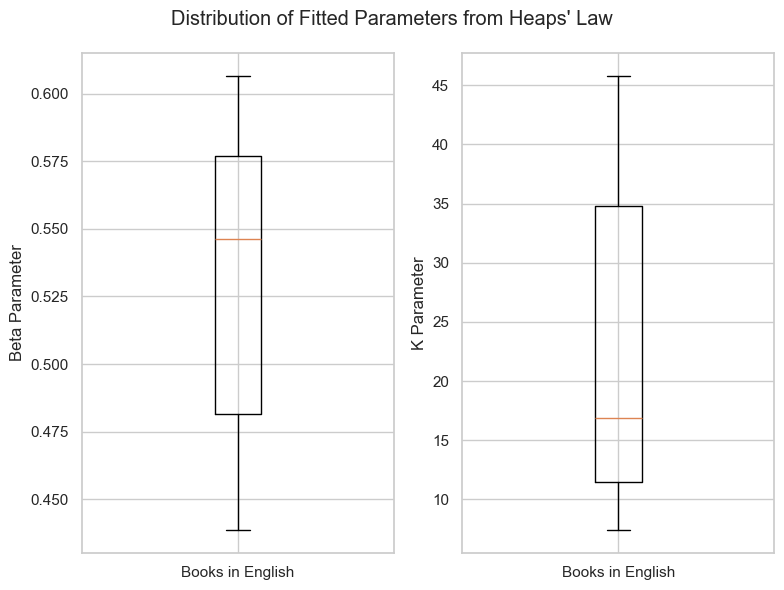

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].boxplot(x=[param[1] for param in parameters])
ax[0].set_ylabel("Beta Parameter")
ax[0].set_xticks([1])
ax[0].set_xticklabels(["Books in English"])

ax[1].boxplot(x=[param[0] for param in parameters])
ax[1].set_ylabel("K Parameter")
ax[1].set_xticks([1])
ax[1].set_xticklabels(["Books in English"])
fig.suptitle("Distribution of Fitted Parameters from Heaps' Law")
plt.tight_layout()

This is curious. We will do the following: We'll perform single-runs through all the books and store their fitted results by language.

In [8]:
parameters: List[Tuple[str, int, int]] = []
for lang in languages:
    books = os.listdir(f"../data/processed/books/{lang}/")
    for book in books:
        book_id = int(book.removesuffix(".txt"))
        book_info = catalog.loc[book_id]

        print(f"Processing book: {book_id} - {book_info['title']} by {book_info['authors']}")
        with open(os.path.join(f"../data/processed/books", lang, book), "r", encoding="utf-8") as file:
            words = file.read().split()
        print(f"  Total words in book: {len(words)}")
        words_processed, vocab_sizes, _ = analyze_vocabulary_growth(words)
        model = LinearRegression()
        model.fit(np.log(words_processed).reshape(-1, 1), np.log(vocab_sizes).reshape(-1, 1))
        beta_ols = model.coef_[0][0]
        K_ols = np.exp(model.intercept_[0])
        print(f"  Fitted parameters with OLS: K = {K_ols:.4f}, beta = {beta_ols:.4f}")
        (beta_curve_fit, K_curve_fit), pcov = curve_fit(
            func_power_law, words_processed, vocab_sizes, p0=[beta_ols, K_ols]
        )
        print(f"  Fitted parameters with curve_fit: K = {K_curve_fit:.4f}, beta = {beta_curve_fit:.4f}")

        parameters.append((lang, K_curve_fit, beta_curve_fit))
parameters = pd.DataFrame(parameters, columns=["language", "K", "beta"])

Processing book: 16543 - Trekkerswee Met tekeninge van J.H. Pierneef by Totius
  Total words in book: 11991
  Fitted parameters with OLS: K = 2.6864, beta = 0.7448
  Fitted parameters with curve_fit: K = 4.1197, beta = 0.6954
Processing book: 18203 - Die prosa van die twede Afrikaanse beweging by Schoonees, P. C. (Pieter Cornelis)
  Total words in book: 102316
  Fitted parameters with OLS: K = 3.1228, beta = 0.7364
  Fitted parameters with curve_fit: K = 4.2514, beta = 0.7079
Processing book: 19729 - Oom Gert Vertel en Ander Gedigte by Leipoldt, C. Louis (Christiaan Louis)
  Total words in book: 23745
  Fitted parameters with OLS: K = 4.2458, beta = 0.6779
  Fitted parameters with curve_fit: K = 8.0594, beta = 0.6093
Processing book: 42302 - Digters uit Suid-Afrika  Bloemlesing uit die poësie van die Twede Afrikaanse-Taalbeweging by Celliers, Jan F. E. (Jan François Elias);Leipoldt, C. Louis (Christiaan Louis);Malherbe, Daniel François;Totius
  Total words in book: 24300
  Fitted param

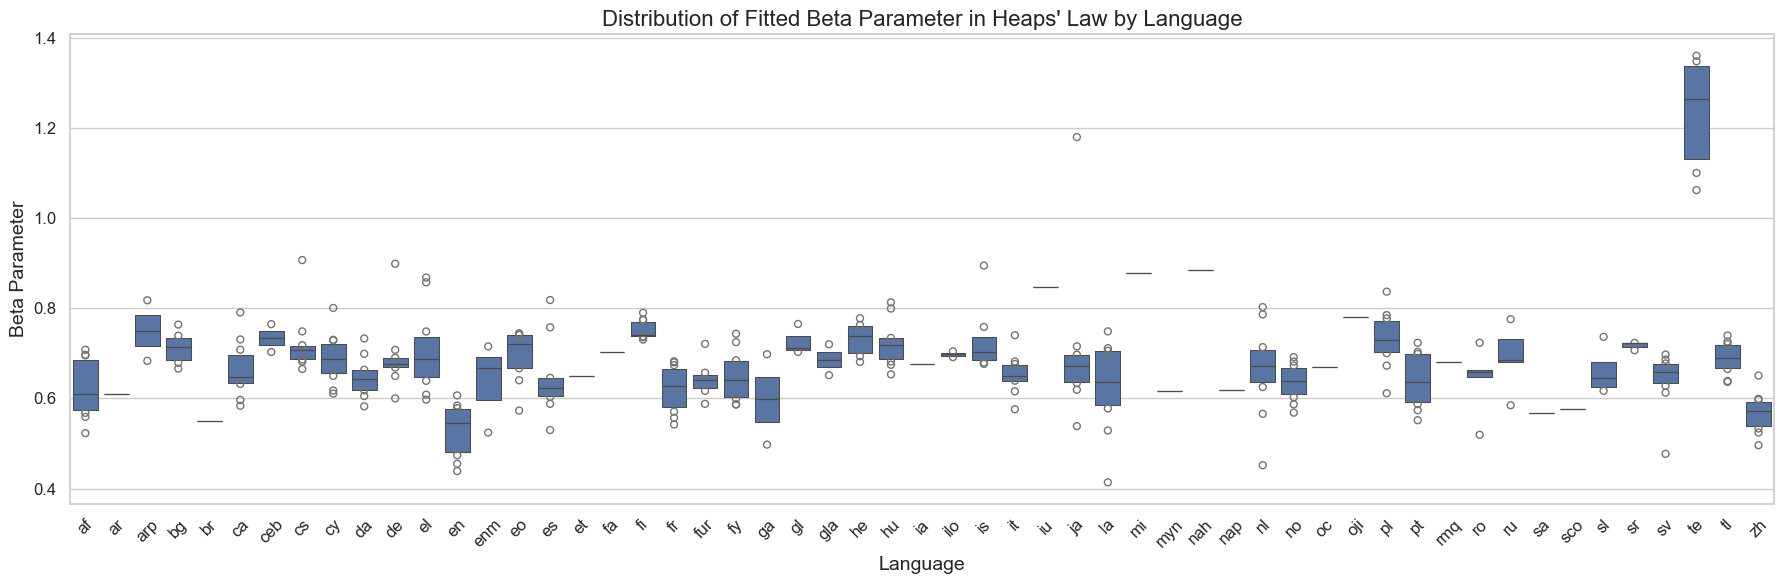

In [9]:
plt.figure(figsize=(18, 6))
sns.boxenplot(y="beta", x="language", data=parameters)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Language", fontsize=14)
plt.ylabel("Beta Parameter", fontsize=14)
plt.title("Distribution of Fitted Beta Parameter in Heaps' Law by Language", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/figures/heaps-by-language-beta.png", dpi=300)
plt.show()